# 4 puntos. Esa es la distancia entre lo que la evolución programó... y el azar puro.

4196 personas de todo el mundo escucharon pares de sonidos de animales. Sin saber cuál preferían los propios animales, eligieron *el mismo* un 54% de las veces. Suena poco — hasta que miras qué animales y qué sonidos disparan la coincidencia.

---

**Paper:** James, L.S. et al. (2026). *Humans share acoustic preferences with other animals.* Science.
DOI: [10.1126/science.aea1202](https://doi.org/10.1126/science.aea1202)

**Datos:** [github.com/themusiclab/animal-sounds](https://github.com/themusiclab/animal-sounds) (48,567 trials, 16 especies, 168 estímulos)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-26-musica-preferencias-animales/notebook.ipynb)

▶️ [Ver el video](https://youtube.com/watch?v=29gpV1ttp6s)

## El experimento

Darwin sospechaba que los animales "tienen casi el mismo gusto por lo bello que nosotros". Un siglo y medio después, este equipo lo testea.

Para cada especie, ya se sabe qué sonidos prefieren (de décadas de estudios previos). Le ponen esos mismos pares de sonidos a humanos — sin decirles nada — y miden si eligen el mismo que el animal.

16 especies. 4 grupos: aves, ranas, insectos, mamíferos. 10 rasgos acústicos (adorno, frecuencia, complejidad...). Y 4196 personas de todo el mundo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CHANCE = 0.50               # Nivel de azar (50/50)
FUENTE = 'Fuente: James et al. (2026), Science | Datos: github.com/themusiclab/animal-sounds'
COLOR_AVES = '#2563EB'      # Azul CaM
COLOR_RANAS = '#059669'     # Emerald
COLOR_INSECTOS = '#D97706'  # Amber
COLOR_MAMIFEROS = '#7C3AED' # Violeta
COLOR_AZAR = '#DC2626'      # Rojo

COLORES_CATEGORIA = {
    'Bird': COLOR_AVES,
    'Frog': COLOR_RANAS,
    'Insect': COLOR_INSECTOS,
    'Mammal': COLOR_MAMIFEROS
}
NOMBRES_CATEGORIA = {
    'Bird': 'Aves',
    'Frog': 'Ranas',
    'Insect': 'Insectos',
    'Mammal': 'Mamíferos'
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
especies = pd.read_csv('datos/acuerdo_por_especie.csv')
rasgos = pd.read_csv('datos/acuerdo_por_rasgo.csv')
estimulos = pd.read_csv('datos/estimulos_fuerza_vs_acuerdo.csv')
features = pd.read_csv('datos/features_acusticos.csv')

print(f"Especies: {len(especies)}")
print(f"Rasgos acústicos: {len(rasgos)}")
print(f"Estímulos individuales: {len(estimulos)}")
print(f"Features acústicos: {len(features)} estímulos × {len(features.columns)-1} features")
print(f"\nAcuerdo global: 54.0% (vs 50% azar)")

Especies: 16
Rasgos acústicos: 10
Estímulos individuales: 106
Features acústicos: 168 estímulos × 12 features

Acuerdo global: 54.0% (vs 50% azar)


## Aquí está.

16 especies. Cada punto es una especie — su posición indica qué tanto los humanos coinciden con la preferencia del animal.

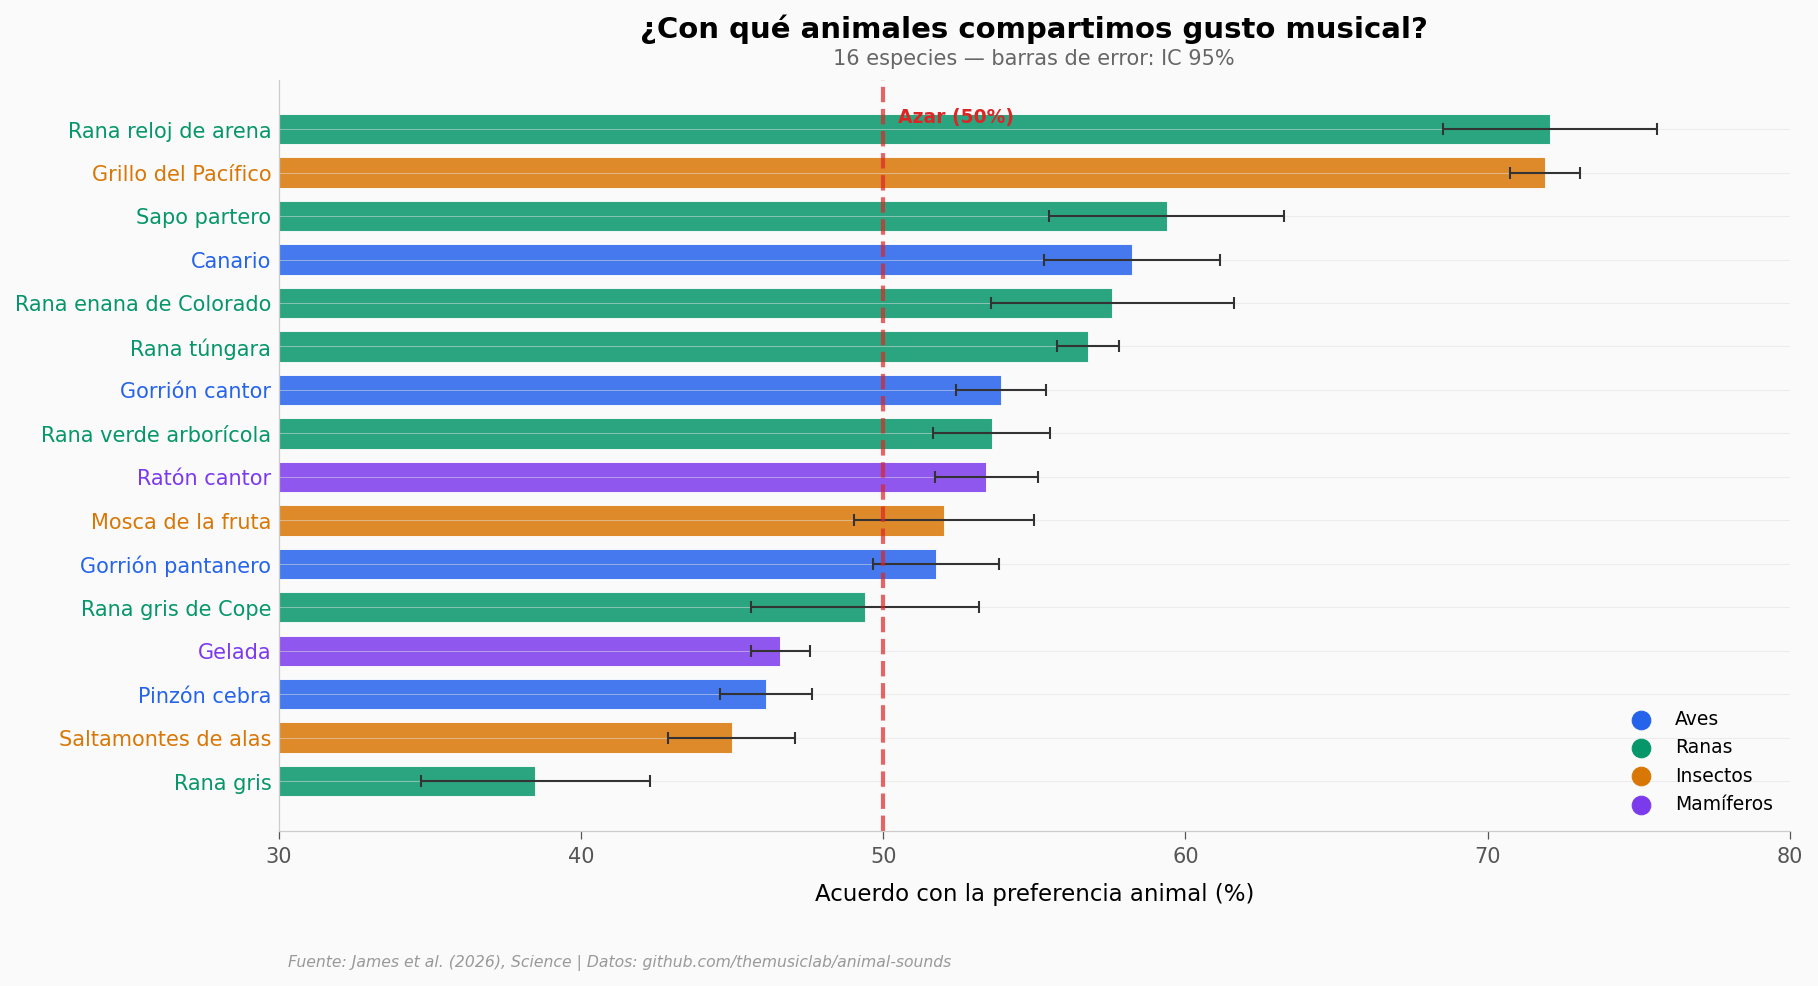

In [2]:
fig, ax = plt.subplots(figsize=(13, 6.5))

# Sort by agreement
sp = especies.sort_values('acuerdo')

y_pos = range(len(sp))
colors = [COLORES_CATEGORIA[cat] for cat in sp['categoria']]

ax.barh(y_pos, sp['acuerdo'] * 100, color=colors, alpha=0.85, height=0.7,
        edgecolor='white', linewidth=0.5)

# Error bars
ax.errorbar(sp['acuerdo'] * 100, y_pos, xerr=sp['se'] * 100 * 1.96,
            fmt='none', color='#333333', capsize=3, capthick=1, linewidth=1)

# Chance line
ax.axvline(x=CHANCE * 100, color=COLOR_AZAR, linewidth=2, linestyle='--', alpha=0.7)
ax.text(CHANCE * 100 + 0.5, len(sp) - 0.5, 'Azar (50%)',
        fontsize=9, color=COLOR_AZAR, fontweight='bold', va='top')

# Species labels
nombres_es = {
    'Hourglass treefrog': 'Rana reloj de arena',
    'Pacific field cricket': 'Grillo del Pacífico',
    'Midwife toad': 'Sapo partero',
    'Canary': 'Canario',
    'Colorado dwarf frog': 'Rana enana de Colorado',
    'Tungara frog': 'Rana túngara',
    'Song sparrow': 'Gorrión cantor',
    'Green tree frog': 'Rana verde arborícola',
    'Singing mouse': 'Ratón cantor',
    'Fruitfly': 'Mosca de la fruta',
    'Swamp sparrow': 'Gorrión pantanero',
    'Cope gray treefrog': 'Rana gris de Cope',
    'Gelada': 'Gelada',
    'Zebra finch': 'Pinzón cebra',
    'Bow-winged grasshopper': 'Saltamontes de alas',
    'Gray treefrog': 'Rana gris'
}
labels = [nombres_es.get(s, s) for s in sp['especie']]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)

# Color ytick labels by category
for tick, cat in zip(ax.get_yticklabels(), sp['categoria']):
    tick.set_color(COLORES_CATEGORIA[cat])

ax.set_xlabel('Acuerdo con la preferencia animal (%)', fontsize=11)
ax.set_xlim(30, 80)
ax.set_title('¿Con qué animales compartimos gusto musical?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '16 especies — barras de error: IC 95%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Legend
for cat, color in COLORES_CATEGORIA.items():
    ax.scatter([], [], color=color, s=80, label=NOMBRES_CATEGORIA[cat])
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/acuerdo_por_especie.png', dpi=200, bbox_inches='tight')
plt.show()

Las ranas dominan la parte alta: la rana reloj de arena y el grillo del Pacífico llegan al **72%** de acuerdo — muy por encima del azar. Los mamíferos (violeta) tienden a quedar cerca o debajo del 50%.

Un dato curioso: la rana gris (*Gray treefrog*) tiene solo **38.5%** de acuerdo. Los humanos preferimos *el sonido que la rana rechaza*. Lo que para ella es atractivo, a nosotros nos suena peor.

¿Qué tienen en común los sonidos donde más coincidimos?

## ¿Qué rasgos del sonido nos unen?

Cada par de sonidos difiere en un rasgo acústico: uno es más adornado, más grave, más complejo, más rápido...

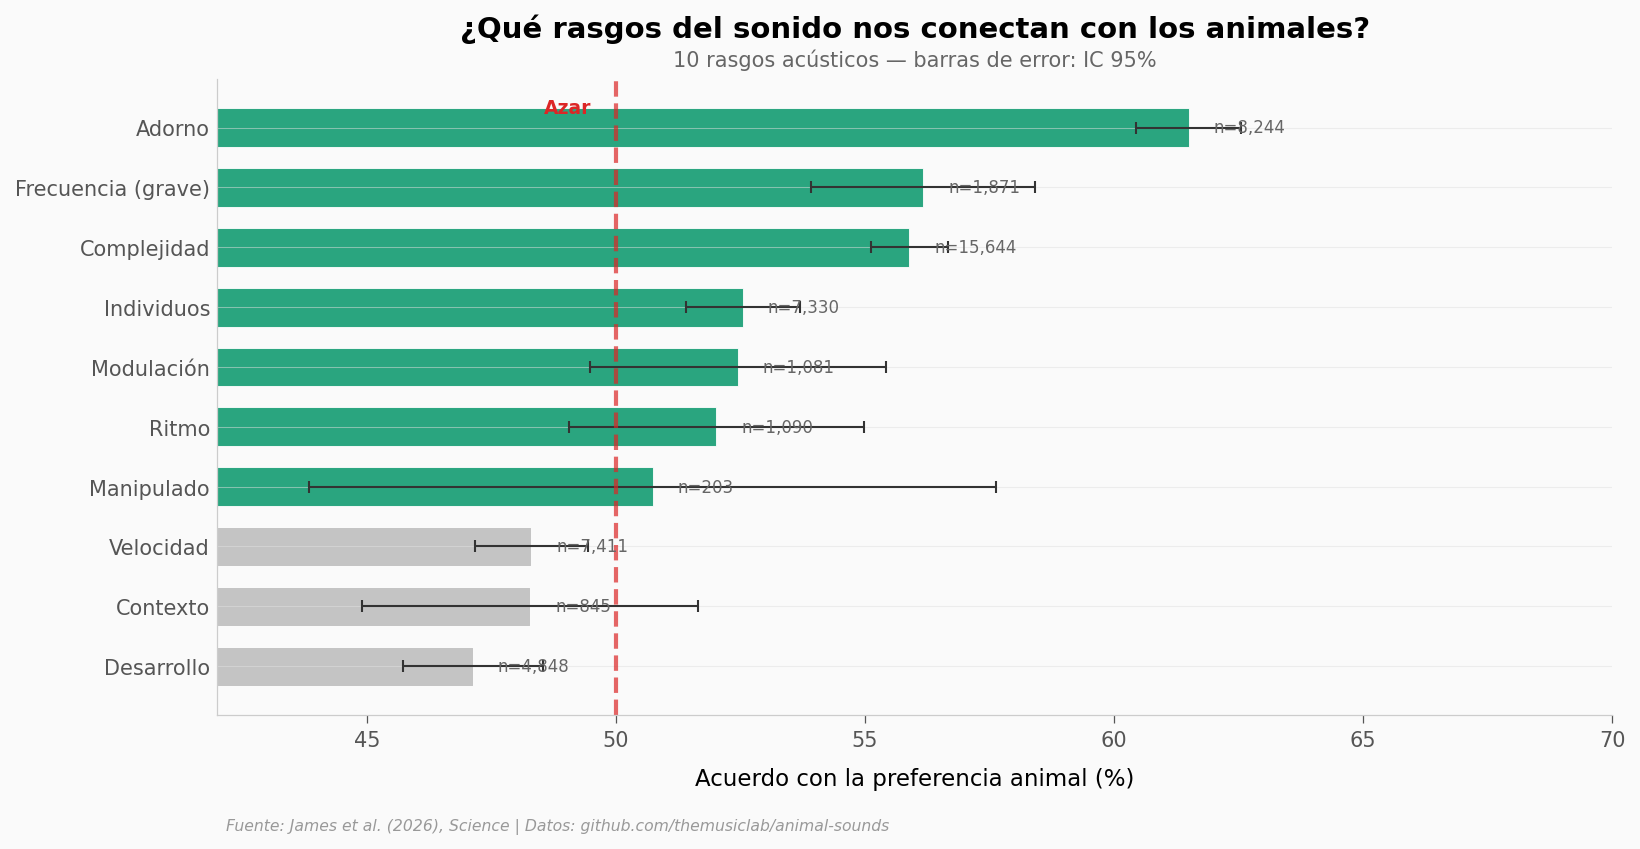

In [3]:
fig, ax = plt.subplots(figsize=(12, 5.5))

r = rasgos.sort_values('acuerdo')

nombres_rasgo = {
    'Adornment': 'Adorno',
    'Frequency': 'Frecuencia (grave)',
    'Complexity': 'Complejidad',
    'Individuals': 'Individuos',
    'AmplitudeModulation': 'Modulación',
    'Rhythm': 'Ritmo',
    'Manipulated': 'Manipulado',
    'Rate': 'Velocidad',
    'Context': 'Contexto',
    'Development': 'Desarrollo'
}

y_pos = range(len(r))
bar_colors = ['#059669' if v > CHANCE else '#BBBBBB' for v in r['acuerdo']]

ax.barh(y_pos, r['acuerdo'] * 100, color=bar_colors, alpha=0.85, height=0.65,
        edgecolor='white', linewidth=0.5)

ax.errorbar(r['acuerdo'] * 100, y_pos, xerr=r['se'] * 100 * 1.96,
            fmt='none', color='#333333', capsize=3, capthick=1, linewidth=1)

ax.axvline(x=CHANCE * 100, color=COLOR_AZAR, linewidth=2, linestyle='--', alpha=0.7)
ax.text(CHANCE * 100 - 0.5, len(r) - 0.5, 'Azar', fontsize=9,
        color=COLOR_AZAR, fontweight='bold', va='top', ha='right')

labels_rasgo = [nombres_rasgo.get(t, t) for t in r['rasgo']]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_rasgo, fontsize=10)

# Annotate n on bars
for i, (_, row) in enumerate(r.iterrows()):
    ax.text(row['acuerdo'] * 100 + 0.5, i, f"n={row['n_trials']:,}",
            fontsize=8, color='#666666', va='center')

ax.set_xlabel('Acuerdo con la preferencia animal (%)', fontsize=11)
ax.set_xlim(42, 70)
ax.set_title('¿Qué rasgos del sonido nos conectan con los animales?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '10 rasgos acústicos — barras de error: IC 95%',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/acuerdo_por_rasgo.png', dpi=200, bbox_inches='tight')
plt.show()

**Adorno** gana por lejos: 61.5% de acuerdo. Cuando un sonido tiene más "florituras" — trinos elaborados, frecuencias moduladas — los humanos y los animales coinciden en preferirlo.

Frecuencia baja (sonidos más graves) y complejidad también nos conectan. Velocidad y desarrollo (sonidos de animales jóvenes vs adultos) quedan cerca del azar.

Ahora, una pregunta más profunda: ¿los estímulos donde el animal tiene una preferencia *fuerte* coinciden más con la preferencia humana?

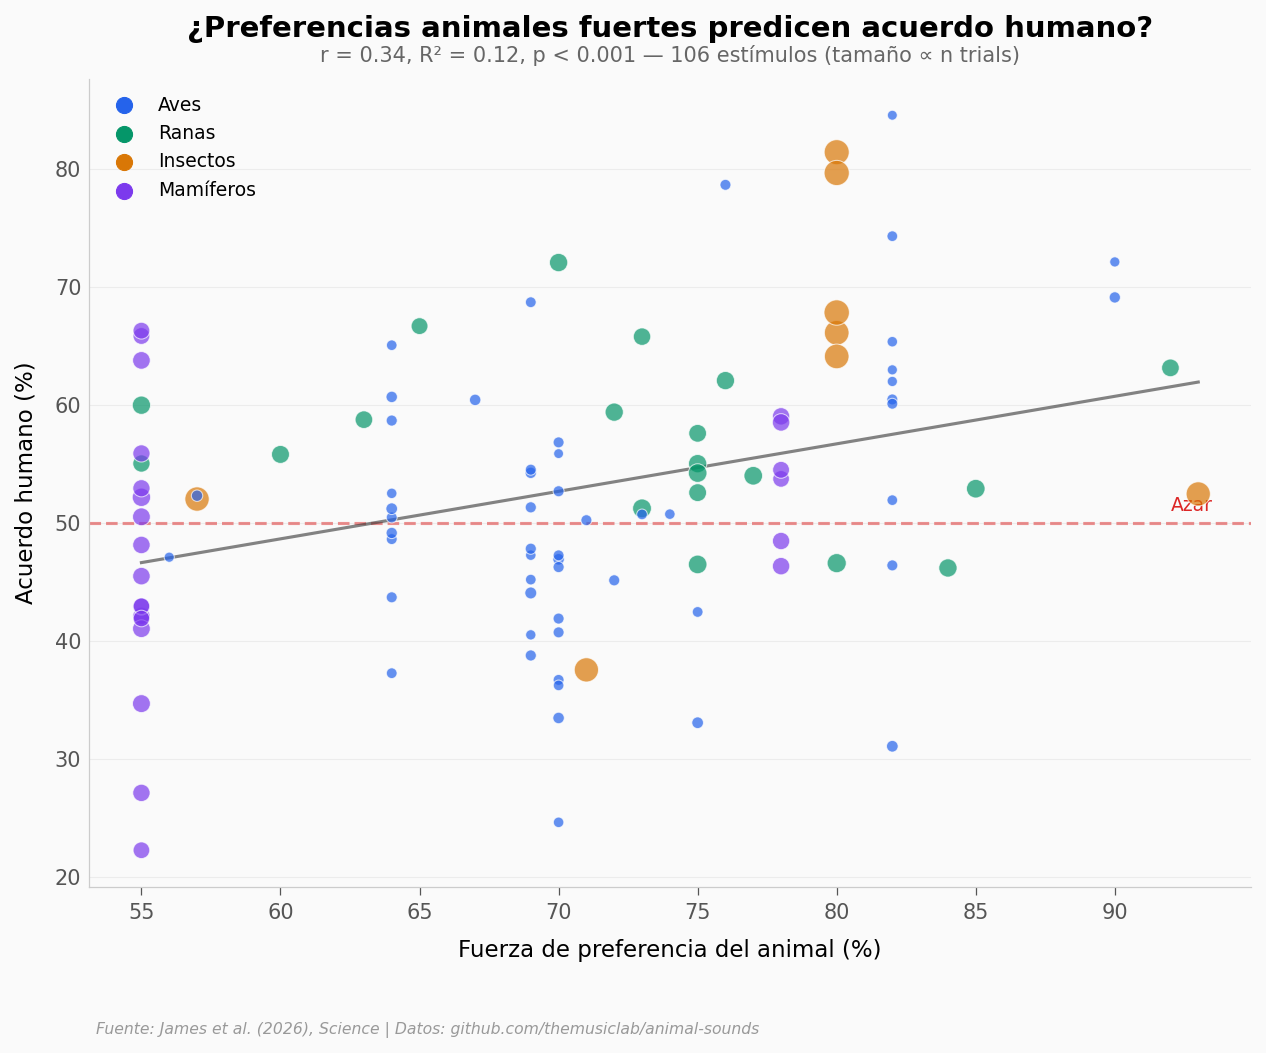

Correlación: r = 0.341, R² = 0.116, p = 3.44e-04
Pendiente: +0.40% acuerdo humano por cada +1% fuerza animal
Spearman ρ = 0.32, p = 0.0009 (confirma dirección)


In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

e = estimulos.copy()
scatter = ax.scatter(e['fuerza_animal'], e['acuerdo_humano'] * 100,
                     c=[COLORES_CATEGORIA[c] for c in e['categoria']],
                     s=e['n_trials'] / 8, alpha=0.7,
                     edgecolors='white', linewidths=0.5, zorder=5)

# Regression line
from scipy import stats
slope, intercept, r, p, se = stats.linregress(e['fuerza_animal'], e['acuerdo_humano'] * 100)
# Spearman (robusto a no-normalidad de fuerza_animal, Shapiro p < 0.001)
rho_sp, p_sp = stats.spearmanr(e['fuerza_animal'], e['acuerdo_humano'])
x_line = np.linspace(e['fuerza_animal'].min(), e['fuerza_animal'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='#333333', linewidth=1.5,
        linestyle='-', alpha=0.6, zorder=4)

ax.axhline(y=CHANCE * 100, color=COLOR_AZAR, linewidth=1.5, linestyle='--', alpha=0.5)
ax.text(92, CHANCE * 100 + 1, 'Azar', fontsize=9, color=COLOR_AZAR)

ax.set_xlabel('Fuerza de preferencia del animal (%)', fontsize=11)
ax.set_ylabel('Acuerdo humano (%)', fontsize=11)
ax.set_title('¿Preferencias animales fuertes predicen acuerdo humano?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'r = {r:.2f}, R² = {r**2:.2f}, p < 0.001 — 106 estímulos (tamaño ∝ n trials)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Legend
for cat, color in COLORES_CATEGORIA.items():
    ax.scatter([], [], color=color, s=60, label=NOMBRES_CATEGORIA[cat])
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/fuerza_vs_acuerdo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Correlación: r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}")
print(f"Pendiente: +{slope:.2f}% acuerdo humano por cada +1% fuerza animal")
print(f"Spearman ρ = {rho_sp:.2f}, p = {p_sp:.4f} (confirma dirección)")

Correlación moderada (r = 0.34, R² = 0.12): cuando el animal tiene una preferencia más fuerte, los humanos tienden a coincidir más — pero solo explica el 12% de la variación. No es un espejo perfecto.

Los puntos verdes (ranas) dominan la esquina superior derecha: preferencias fuertes y alto acuerdo humano. Los violetas (mamíferos) tienden a quedar más abajo.

## ¿Qué tan lejos del azar estamos realmente?

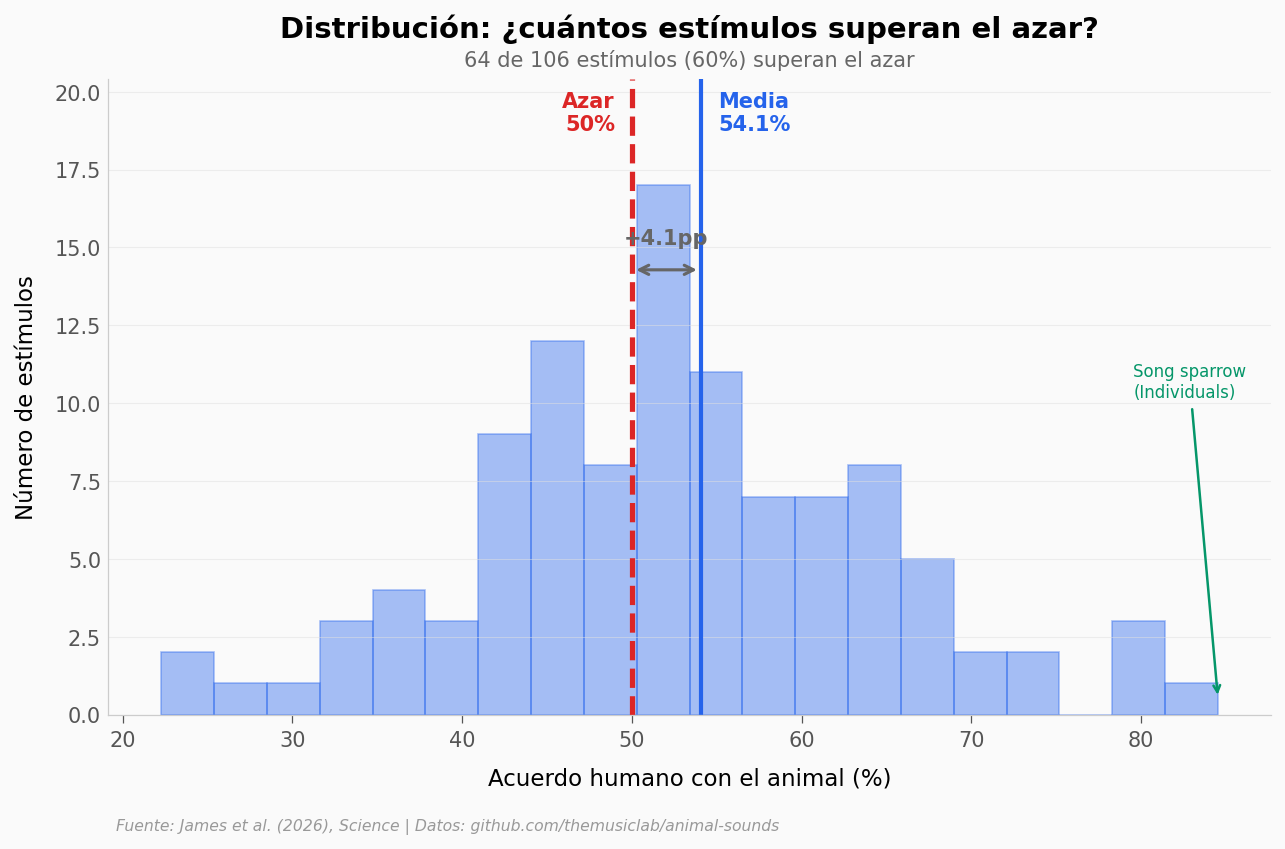

Estímulos > azar: 64/106 (60%)
Media: 54.1%, Mediana: 52.2%
Rango: 22.3% — 84.5%


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

acuerdos = estimulos['acuerdo_humano'] * 100
# Media ponderada por n_trials (consistente con el 54.0% global del paper)
media = np.average(acuerdos, weights=estimulos['n_trials'])

n, bins, patches = ax.hist(acuerdos, bins=20, color='#2563EB', alpha=0.4,
                           edgecolor='#2563EB', linewidth=0.8)

y_max = n.max() * 1.2
ax.set_ylim(0, y_max)

# Lines
ax.axvline(x=CHANCE * 100, color=COLOR_AZAR, linewidth=2.5, linestyle='--')
ax.axvline(x=media, color='#2563EB', linewidth=2)

# Labels
ax.text(CHANCE * 100 - 1, y_max * 0.92, 'Azar\n50%', fontsize=10,
        color=COLOR_AZAR, fontweight='bold', ha='right')
ax.text(media + 1, y_max * 0.92, f'Media\n{media:.1f}%', fontsize=10,
        color='#2563EB', fontweight='bold', ha='left')

# Bidirectional arrow
arrow_y = y_max * 0.7
ax.annotate('', xy=(media, arrow_y), xytext=(CHANCE * 100, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media + CHANCE * 100) / 2, arrow_y + y_max * 0.04,
        f'+{media - CHANCE * 100:.1f}pp', fontsize=10,
        color='#666666', ha='center', fontweight='bold')

# Extremes
max_est = estimulos.loc[estimulos['acuerdo_humano'].idxmax()]
min_est = estimulos.loc[estimulos['acuerdo_humano'].idxmin()]
ax.annotate(f'{max_est["especie"]}\n({max_est["rasgo"]})',
            xy=(max_est['acuerdo_humano'] * 100, 0.5),
            xytext=(max_est['acuerdo_humano'] * 100 - 5, y_max * 0.5),
            fontsize=8, color='#059669',
            arrowprops=dict(arrowstyle='->', color='#059669', lw=1.2))

ax.set_xlabel('Acuerdo humano con el animal (%)', fontsize=11)
ax.set_ylabel('Número de estímulos', fontsize=11)
ax.set_title('Distribución: ¿cuántos estímulos superan el azar?',
             fontsize=14, fontweight='bold', pad=20)

above_chance = (acuerdos > 50).sum()
total = len(acuerdos)
ax.text(0.5, 1.02, f'{above_chance} de {total} estímulos ({above_chance/total*100:.0f}%) superan el azar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_acuerdo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Estímulos > azar: {above_chance}/{total} ({above_chance/total*100:.0f}%)")
print(f"Media: {media:.1f}%, Mediana: {acuerdos.median():.1f}%")
print(f"Rango: {acuerdos.min():.1f}% — {acuerdos.max():.1f}%")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los humanos comparten preferencias acústicas con otros animales | ✅ | 54.0% acuerdo vs 50% azar, p < 10⁻⁶⁹, n = 48,567 trials. Efecto pequeño pero robusto por tamaño muestral |
| Las preferencias correlacionan en fuerza | ⚠️ | r = 0.34, R² = 0.12, p < 0.001. Correlación moderada, solo explica 12% de la variación |
| Mayor acuerdo en sonidos adornados y graves | ✅ | Adorno: 61.5% acuerdo. Frecuencia baja: 56.2%. Ambos significativamente > azar |
| Los humanos responden más rápido cuando coinciden con el animal | ⚠️ | Diferencia de 276ms en medias, pero Cohen's d = 0.015 — efecto negligible. Las medianas son casi idénticas (924 vs 922ms) |
| La experiencia musical está asociada con las preferencias | ⚠️ | r = 0.037 para horas de escucha, r = 0.011 para disfrute. Correlaciones reales pero diminutas |
| Esto "confirma la corazonada de Darwin" | ⚠️ | Los datos son *consistentes con* la conjetura, pero 54% de acuerdo no es evidencia contundente. El abstract dice "consistent with" — no "confirm" en sentido fuerte |

> **Limitaciones:** (1) El acuerdo global de 54% es estadísticamente significativo por el enorme n (48K) pero el efecto es pequeño. (2) La fuerza animal (`AnimalStrength`) proviene de estudios previos con métodos diversos — no es una medida uniforme. (3) Los humanos escucharon sonidos aislados, no en su contexto natural. (4) Variabilidad entre especies es enorme: 38.5% a 72.1%.

## Ahora tú

1. **¿Los músicos coinciden más con los animales?** Los datos incluyen `musicSkill` y `musicLessons`. ¿Hay diferencia entre quienes tienen formación musical y quienes no?

2. **¿Qué features acústicos predicen el acuerdo?** El archivo `features_acusticos.csv` tiene 12 medidas (pitch, roughness, entropy...). ¿Alguna correlaciona con el acuerdo humano?

3. **¿Los países difieren?** Los participantes vienen de todo el mundo. ¿La cultura modifica la preferencia? (Necesitarías el dataset completo: `animal-sounds-data.csv` del repo original)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué feature acústico predice mejor el acuerdo humano?

# Merge features con acuerdo por estímulo (via audio_bueno → Stimuli)
merged = estimulos.merge(features, left_on='audio_bueno', right_on='Stimuli', how='inner')
print(f"Estímulos con features acústicos: {len(merged)}")

feature_cols = ['Pitch', 'Duration', 'Roughness', 'ShannonEntropy',
                'SpectralCentroid', 'Brightness', 'AMVariance']

print("\nCorrelación feature acústico → acuerdo humano (Spearman ρ):")
print("-" * 50)
from scipy import stats
for col in feature_cols:
    valid = merged.dropna(subset=[col])
    if len(valid) < 3:
        print(f"  {col:20s}: sin datos suficientes (n={len(valid)})")
        continue
    r, p = stats.spearmanr(valid[col], valid['acuerdo_humano'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {col:20s}: r = {r:+.3f}  p = {p:.3f} {sig}")

Estímulos con features acústicos: 106

Correlación feature acústico → acuerdo humano (Spearman ρ):
--------------------------------------------------
  Pitch               : r = -0.024  p = 0.808 
  Duration            : r = -0.363  p = 0.000 ***
  Roughness           : r = +0.031  p = 0.750 
  ShannonEntropy      : r = -0.268  p = 0.006 **
  SpectralCentroid    : r = +0.025  p = 0.800 
  Brightness          : r = +0.051  p = 0.604 
  AMVariance          : r = +0.098  p = 0.318 


---

### Créditos

- **Paper:** James, L.S., Woolley, S.C., Sakata, J.T., Hilton, C.B., Ryan, M.J. & Mehr, S.A. (2026). Humans share acoustic preferences with other animals. *Science.*
- **DOI:** [10.1126/science.aea1202](https://doi.org/10.1126/science.aea1202)
- **Datos:** [github.com/themusiclab/animal-sounds](https://github.com/themusiclab/animal-sounds)
- **Licencia datos:** [MIT License](https://github.com/themusiclab/animal-sounds/blob/main/LICENSE.txt)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)